## Dataset helpers testing script

In [1]:
import torch
import numpy as np
import pandas as pd
from data_utils import get_X_features, get_reference_features, ZINBDataset
from model_utils import OrionVAE, train_orion, plot_training_results, evaluate_test_set
from model_utils import train_orion
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

print("Loading data...")

raw_df = pd.read_csv("GSE270497_All.Counts.exp.txt", sep='\t', index_col=0)
metadata_cols = ['smallRNApreName', 'smallRNASequence']
counts_matrix = raw_df.drop(columns=metadata_cols)
counts_matrix = counts_matrix.T #Transpose for PyTorch

labels = np.array([1]*120 + [0]*60)

print(f"Final Data Shape: {counts_matrix.shape}") # Should be (180, ~3500)
print(f"Labels Shape: {labels.shape}")

signal_cols = get_X_features(counts_matrix, labels, n_features=500)
ref_cols = get_reference_features(counts_matrix, n_features=50)

print(f"Selected {len(signal_cols)} signal RNAs and {len(ref_cols)} reference RNAs.")

dataset = ZINBDataset(counts_matrix, labels, signal_cols, ref_cols)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

x_batch, r_batch, l_batch, y_batch = next(iter(loader))
print(f"Batch X Shape: {x_batch.shape}") # Should be [32, 500]
print(f"Batch R Shape: {r_batch.shape}") # Should be [32, 50]
print("Data pipeline ready!")

Loading data...
Final Data Shape: (180, 3538)
Labels Shape: (180,)
Selecting top 500 signal features...
Selected 500 signal RNAs and 50 reference RNAs.
Batch X Shape: torch.Size([32, 500])
Batch R Shape: torch.Size([32, 50])
Data pipeline ready!


## Running the model
1. Split data into training and validation sets.
2. Initialize the model with the correct dimensions.
3. Execute the training loop using the train_orion function.

In [2]:
# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
print("Loading data...")
raw_df = pd.read_csv("GSE270497_All.Counts.exp.txt", sep='\t', index_col=0)
metadata_cols = ['smallRNApreName', 'smallRNASequence']
counts_matrix = raw_df.drop(columns=metadata_cols).T
labels = np.array([1]*120 + [0]*60)

# Select features
signal_cols = get_X_features(counts_matrix, labels, method="mannwhitneyu", n_features=500)
ref_cols = get_reference_features(counts_matrix, n_features=50)

Loading data...
Selecting top 500 signal features...


In [4]:
# 3. Create Train/Validation Split
# 'stratify=labels' ensures both sets have the same ratio of cancer/healthy samples.
indices = np.arange(len(labels))
train_val_idx, test_idx = train_test_split(
    indices, 
    test_size=0.15, 
    stratify=labels, 
    random_state=42
)
train_idx, val_idx = train_test_split(
    train_val_idx, 
    test_size=0.176, 
    stratify=labels[train_val_idx], 
    random_state=42
)

full_dataset = ZINBDataset(counts_matrix, labels, signal_cols, ref_cols)
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)
full_loader  = DataLoader(full_dataset,  batch_size=1, shuffle=False)

print(f"--- Dataset Split Summary ---")
print(f"Training Samples:   {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Test Samples:       {len(test_dataset)} (Hold-out)")

--- Dataset Split Summary ---
Training Samples:   126
Validation Samples: 27
Test Samples:       27 (Hold-out)


In [5]:
# 4. Initialize Orion Model
# x_dim must match n_features in get_X_features
# r_dim must match n_features in get_reference_features
model = OrionVAE(
    x_dim=len(signal_cols), 
    r_dim=len(ref_cols), 
    z_dim=32   # The 'z' latent space dimension
)

In [6]:
print("\n--- Starting Training ---")
history = train_orion(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=150,      
    lr=1e-3,         # Adam optimizer standard LR
    device=device
)
torch.save(model.state_dict(), "orion_breast_cancer_model.pth")
print("\nTraining complete. Model weights saved to 'orion_breast_cancer_model.pth'")


--- Starting Training ---
Starting training on cpu for 150 epochs...
Epoch 005 | Loss: 1610.7130 | Val AUC: 0.9877 | Val Acc: 0.8519
Epoch 010 | Loss: 1529.2249 | Val AUC: 0.9568 | Val Acc: 0.8519
Epoch 015 | Loss: 1491.3051 | Val AUC: 0.9753 | Val Acc: 0.8148
Epoch 020 | Loss: 1463.6180 | Val AUC: 0.9568 | Val Acc: 0.8148
Epoch 025 | Loss: 1429.6586 | Val AUC: 0.9753 | Val Acc: 0.9259
Epoch 030 | Loss: 1403.2569 | Val AUC: 0.9691 | Val Acc: 0.8889
Epoch 035 | Loss: 1375.8477 | Val AUC: 0.9753 | Val Acc: 0.8889
Epoch 040 | Loss: 1346.2516 | Val AUC: 0.9753 | Val Acc: 0.9259
Epoch 045 | Loss: 1346.1595 | Val AUC: 0.9630 | Val Acc: 0.8889
Epoch 050 | Loss: 1307.4442 | Val AUC: 0.9691 | Val Acc: 0.8889
Epoch 055 | Loss: 1299.5277 | Val AUC: 0.9568 | Val Acc: 0.9259
Epoch 060 | Loss: 1283.7380 | Val AUC: 0.9383 | Val Acc: 0.9259
Epoch 065 | Loss: 1261.3491 | Val AUC: 0.9444 | Val Acc: 0.8889
Epoch 070 | Loss: 1256.8025 | Val AUC: 0.9691 | Val Acc: 0.8519
Epoch 075 | Loss: 1239.1477 | Val 

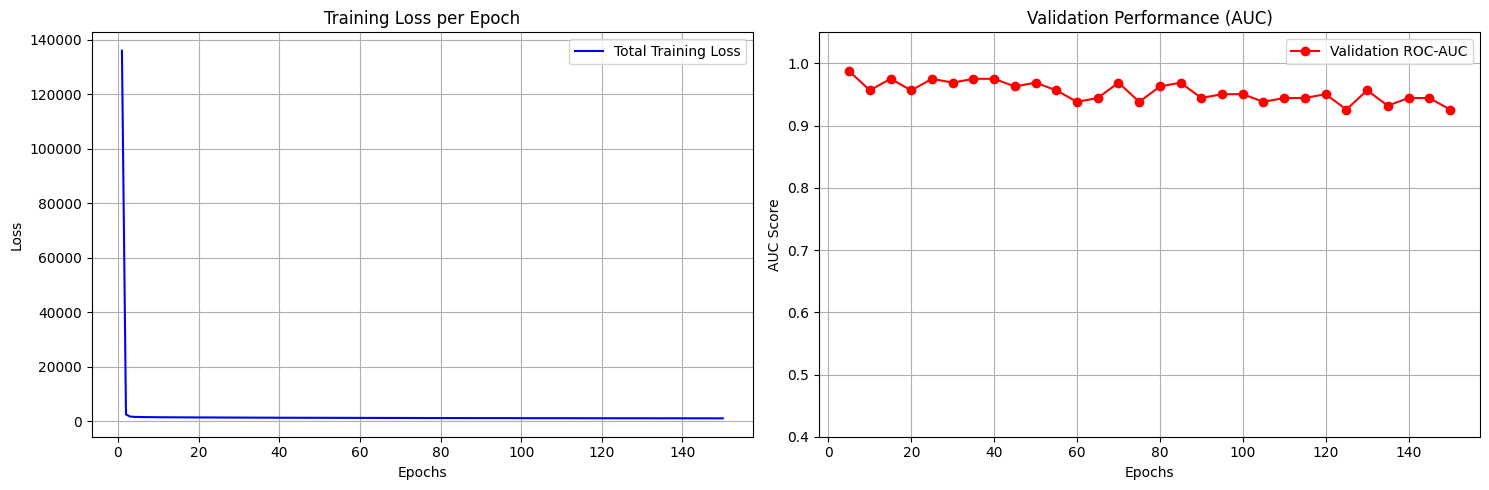

In [7]:
plot_training_results(history)

## Test the model

In [8]:
from model_utils import OrionLoss
loss_fn = OrionLoss(beta=0.01, gamma=10.0).to(device)
test_probs, test_targets = evaluate_test_set(model, test_loader, loss_fn, device)

------------------------------
FINAL TEST RESULTS (N=27)
------------------------------
Test Loss:  2753.7820
ROC-AUC:    1.0000
Accuracy:   0.9630
Precision:  1.0000 (Positive Predictive Value)
Recall:     0.9444 (Sensitivity)
F1-Score:   0.9714
------------------------------


c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


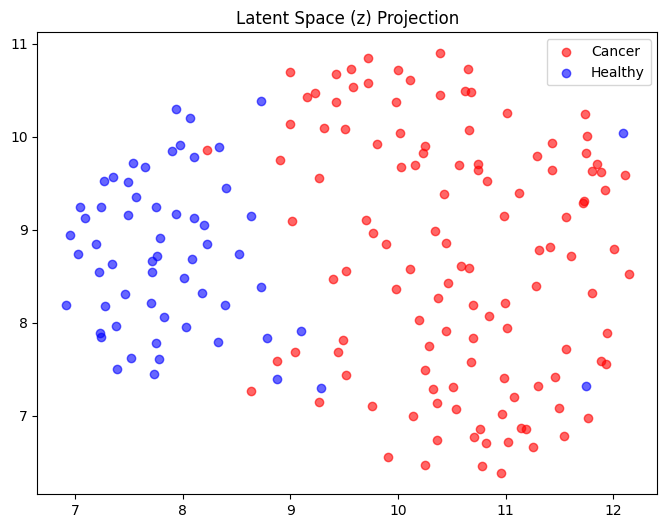

In [9]:
from umap import UMAP
import matplotlib.pyplot as plt
def plot_latent_space(model, loader, device):
    model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        for x, r, l, y in loader:
            z, _, _, _, _, _ = model.encoder(x.to(device), r.to(device))
            latents.append(z.cpu().numpy())
            labels.append(y.numpy())
            
    latents = np.concatenate(latents)
    labels = np.concatenate(labels).flatten()
    
    # Reduce 32D latent space to 2D for plotting
    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(latents)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding[labels==1, 0], embedding[labels==1, 1], c='red', label='Cancer', alpha=0.6)
    plt.scatter(embedding[labels==0, 0], embedding[labels==0, 1], c='blue', label='Healthy', alpha=0.6)
    plt.title("Latent Space (z) Projection")
    plt.legend()
    plt.show()

plot_latent_space(model, full_loader, device)

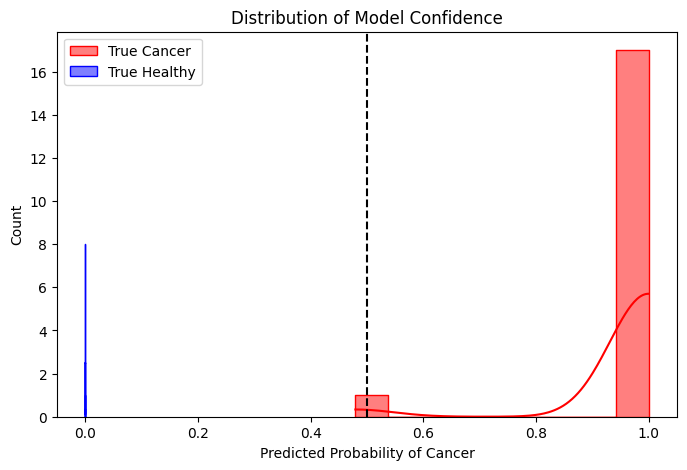

In [12]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(test_probs[test_targets==1], color="red", label="True Cancer", kde=True, element="step")
sns.histplot(test_probs[test_targets==0], color="blue", label="True Healthy", kde=True, element="step")
plt.axvline(0.5, color='black', linestyle='--') # Decision Threshold
plt.title("Distribution of Model Confidence")
plt.xlabel("Predicted Probability of Cancer")
plt.legend()
plt.show()

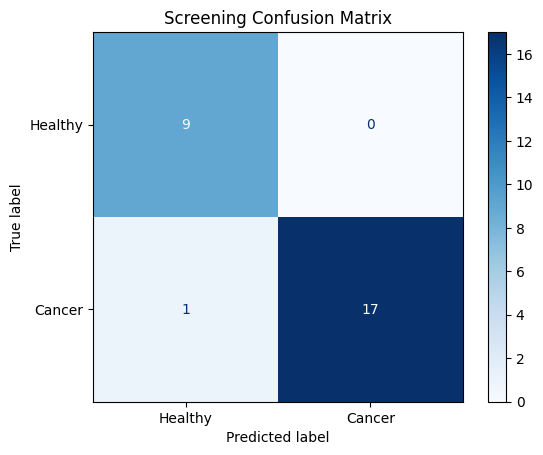

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
preds_binary = (test_probs > 0.5).astype(int)
cm = confusion_matrix(test_targets, preds_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Cancer'])
disp.plot(cmap='Blues')
plt.title("Screening Confusion Matrix")
plt.show()